In [50]:
from typing import TypedDict,List
import random
from langgraph.graph import StateGraph, START ,END


In [51]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int    

In [52]:
def greeting_node(state: AgentState) -> AgentState:
    state['name'] = f'Hi there, {state['name']}'
    state['counter'] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    state['number'].append(random.randint(0,10))
    state['counter'] += 1

    return state

def should_continue(state: AgentState):
    if state['counter'] < 5:
        print(f"ENTERING LOOP: {state['counter']}")
        return "loop"
    else: 
        return "exit"


In [53]:
graph = StateGraph(AgentState)

graph.add_node('greeting_node', greeting_node)
graph.add_node('random_node', random_node)

graph.add_edge(START, 'greeting_node')
graph.add_edge('greeting_node', 'random_node')
graph.add_conditional_edges(
    'random_node',
    should_continue,
    {
        'loop' : 'random_node', 
        'exit' : END
    }
)

app = graph.compile()

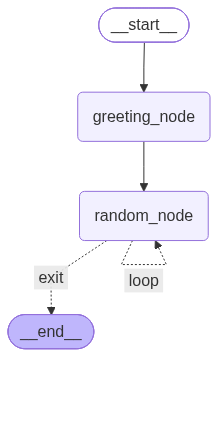

In [54]:
from IPython.display import Image, display

# Vẽ và hiển thị đồ thị của LangGraph
display(Image(app.get_graph().draw_mermaid_png()))

In [56]:
res = app.invoke({'name': 'Son', 'number' : []})
print(res)

ENTERING LOOP: 1
ENTERING LOOP: 2
ENTERING LOOP: 3
ENTERING LOOP: 4
{'name': 'Hi there, Son', 'number': [1, 4, 5, 1, 8], 'counter': 5}


ModuleNotFoundError: No module named 'langchain_openai'